<a href="https://colab.research.google.com/github/Nipun-Pasindu/Statistical-Learning-E23210/blob/main/KalmanFilter_Assignement_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## # Q. Analytical Derivation

### 1. Show that $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$

Given the state update equation:


$$x^{-}_k = A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}$$

Because $x^{+}_{k-1}$ and $w_{k-1}$ are independent Gaussian random variables, their linear combination must also yield a Gaussian distribution. We compute the mean ($m_k^-$) and covariance ($P_k^-$) using linear expectation rules:

* **Mean ($m_k^-$):**

$$\mathbb{E}[x^-_k] = \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}] = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$



Since $\mathbb{E}[x^{+}_{k-1}] = m_{k-1}$ and $\mathbb{E}[w_{k-1}] = 0$:

$$m_k^- = A_{k-1}m_{k-1}$$


* **Covariance ($P_k^-$):**

$$P_k^- = \text{Var}(x^-_k) = \text{Var}(A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1})$$



Since the state and process noise are mutually independent, the covariance matrix expands as:

$$P_k^- = A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$


$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$



---

### 2. Show that $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$

Given the measurement equation:


$$y^{-}_k = H_k x^{-}_k + z_k$$

* **Mean:**

$$\mathbb{E}[y^{-}_k] = \mathbb{E}[H_k x^{-}_k + z_k] = H_k \mathbb{E}[x^{-}_k] + \mathbb{E}[z_k] = H_k m_k^-$$


* **Covariance:**

$$\text{Var}(y^{-}_k) = \text{Var}(H_k x^{-}_k + z_k) = H_k \text{Var}(x^{-}_k)H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$



---

### 3. Joint Distribution Derivation

To find the joint distribution of $\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix}$, we evaluate the cross-covariance term:


$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T\right]$$

Substitute the measurement error $(y_k^- - H_k m_k^-) = H_k(x_k^- - m_k^-) + z_k$:


$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T\right]$$

$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T\right] + \mathbb{E}\left[(x_k^- - m_k^-)z_k^T\right]$$

Because $x_k^-$ and $z_k$ are uncorrelated, the final cross-term expectation becomes zero:


$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T \implies \text{Cov}(y_k^-, x_k^-) = H_k P_k^-$$

Combining the individual variances and cross-covariances into a single block matrix gives the desired joint multivariate distribution:


$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

---

### 4. Conditional Distribution (Measurement Update)

According to the standard **Gaussian Conditioning Theorem**, if a joint system is distributed as:


$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix}\right)$$

Then the conditional distribution is:


$$X \mid Y=y \sim \mathscr{N}\left(\mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y), \; \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}\right)$$

Mapping $X \rightarrow x_k^-$, $Y \rightarrow y_k^-$, and $y \rightarrow y^{\mathrm{obs}}_{k}$:

* **Kalman Gain ($K_k$):** Let $K_k = \Sigma_{XY}\Sigma_{YY}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$
* **Updated Mean ($m_k$):** $m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$
* **Updated Covariance ($P_k$):** $P_k = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k) P_k^-$

---

### 5. Conditional Expectation and Variance

The conditional expectation and variance are the parameters of the conditional distribution evaluated directly in Question 4:


$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k$$

$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k$$

## # Q. 1-D Example

### 1. Show that $m_k^- = a\,m_{k-1}$ and $P_k^- = a^2 P_{k-1} + q$

Given the 1-D state equation:


$$x^-_k = a\,x^+_{k-1} + w_{k-1}, \quad w_{k-1} \sim \mathscr{N}(0, q)$$

* **Predictive Mean ($m_k^-$):**
Taking the mathematical expectation ($\mathbb{E}$) on both sides:

$$m_k^- = \mathbb{E}[x^-_k] = \mathbb{E}[a\,x^+_{k-1} + w_{k-1}] = a\,\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}]$$



Since $\mathbb{E}[x^+_{k-1}] = m_{k-1}$ and the process noise is zero-mean ($\mathbb{E}[w_{k-1}] = 0$):

$$m_k^- = a\,m_{k-1}$$


* **Predictive Covariance ($P_k^-$):**
Taking the variance ($\text{Var}$) on both sides:

$$P_k^- = \text{Var}(x^-_k) = \text{Var}(a\,x^+_{k-1} + w_{k-1})$$



Because the previous state $x^+_{k-1}$ and the process noise $w_{k-1}$ are mutually independent, the variance of their sum equals the sum of their variances:

$$P_k^- = a^2 \text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1})$$


$$P_k^- = a^2 P_{k-1} + q$$



---

### 2. Show the Measurement Update Equations

Given the measurement update parameters:


$$m_k = m_k^- + K_k\,v_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$

$$P_k = (1 - K_k h)\,P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

From the general multivariate Kalman filter conditioning step, the innovation covariance $S_k$ and Kalman gain $K_k$ are:


$$S_k = H_k P_k^- H_k^T + \Sigma_m \implies S_k = h^2 P_k^- + r$$

$$K_k = P_k^- H_k^T S_k^{-1} \implies K_k = \frac{P_k^- h}{h^2 P_k^- + r} = \frac{P_k^- h}{S_k}$$

* **Substituting into the Mean ($m_k$):**
The innovation residual is $v_k = y^{\mathrm{obs}}_k - H_k m_k^- = y^{\mathrm{obs}}_k - h\,m_k^-$.

$$m_k = m_k^- + K_k v_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$


* **Substituting into the Covariance ($P_k$):**

$$P_k = (1 - K_k h) P_k^- = \left(1 - \frac{P_k^- h}{S_k} \cdot h\right) P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$



---

### 3. Show that $p(y^-_k \mid Y_{k-1}) = \mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$

The predictive measurement distribution describes the expected observation $y^-_k$ *before* it is actually observed, relying strictly on the prior history $Y_{k-1}$.
Given the observation model:


$$y^-_k = h\,x^-_k + z_k, \quad z_k \sim \mathscr{N}(0, r)$$

* **Mean:** $\mathbb{E}[y^-_k \mid Y_{k-1}] = h\,\mathbb{E}[x^-_k \mid Y_{k-1}] + \mathbb{E}[z_k] = h\,m_k^-$
* **Variance:** Since $x^-_k$ and $z_k$ are independent, $\text{Var}(y^-_k \mid Y_{k-1}) = h^2 \text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$

Thus, $p(y^-_k \mid Y_{k-1}) = \mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$.

---

### 4. Show that $p(y^-_k \mid Y_k) = \mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr)$

The posterior-predictive distribution evaluates the measurement distribution *after* updating the underlying state vector with the current measurement $y^{\mathrm{obs}}_k$ (meaning it leverages the full set $Y_k$).

We replace the prior state parameters ($m_k^-, P_k^-$) with the freshly optimized filtered parameters ($m_k, P_k$):

* **Mean:** $\mathbb{E}[y^-_k \mid Y_k] = h\,\mathbb{E}[x_k \mid Y_k] + \mathbb{E}[z_k] = h\,m_k$
* **Variance:** $\text{Var}(y^-_k \mid Y_k) = h^2 \text{Var}(x_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$

Thus, $p(y^-_k \mid Y_k) = \mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr)$.

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


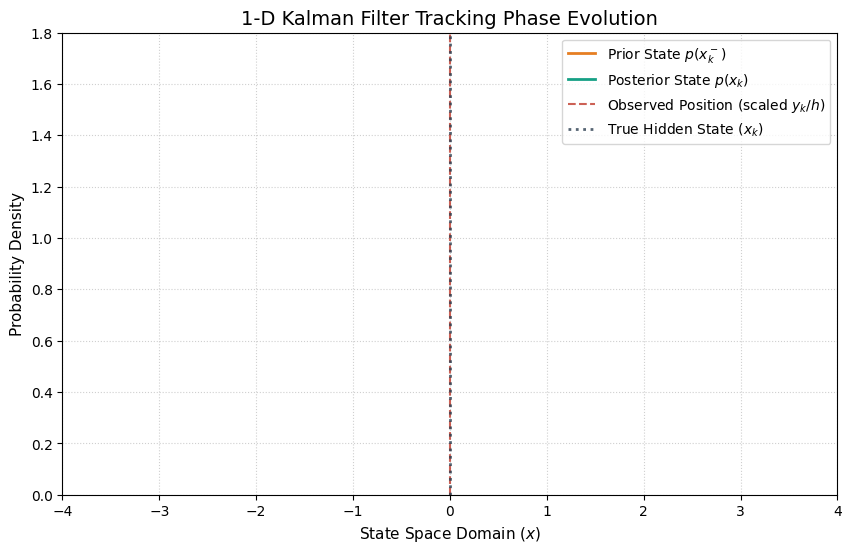

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm

# ==========================================
# 1. Simulation & Model Parameters
# ==========================================
a = 0.95      # State transition scalar
q = 0.20      # Process noise variance
h = 1.20      # Measurement scalar
r = 0.40      # Measurement noise variance

# True initial state and initial filter belief
x_true = 1.0
m = 0.0       # Initial state estimate mean
P = 1.0       # Initial state estimate variance

np.random.seed(42)  # For reproducible simulation trajectories
num_steps = 30

# Pre-generate the true trajectory and noisy measurements
true_states = []
measurements = []
current_x = x_true

for _ in range(num_steps):
    # System evolution: x_k = a*x_{k-1} + w
    current_x = a * current_x + np.random.normal(0, np.sqrt(q))
    # Measurement: y_k = h*x_k + z
    current_y = h * current_x + np.random.normal(0, np.sqrt(r))

    true_states.append(current_x)
    measurements.append(current_y)

# ==========================================
# 2. Animation Setup
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-5, 5, 1000)

# Initialize plot line structures
prior_line, = ax.plot([], [], label='Prior State $p(x_k^-)$', color='#E67E22', lw=2)
post_line, = ax.plot([], [], label='Posterior State $p(x_k)$', color='#16A085', lw=2)
obs_line = ax.axvline(0, color='#C0392B', linestyle='--', alpha=0.8, label='Observed Position (scaled $y_k/h$)')
true_line = ax.axvline(0, color='#2C3E50', linestyle=':', alpha=0.8, lw=2, label='True Hidden State ($x_k$)')

ax.set_xlim(-4, 4)
ax.set_ylim(0, 1.8)
ax.set_title('1-D Kalman Filter Tracking Phase Evolution', fontsize=14)
ax.set_xlabel('State Space Domain ($x$)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

# ==========================================
# 3. Animation Framework Loop
# ==========================================
# Variables to hold running filter updates across frame calls
filter_state = {'m': m, 'P': P}

def init():
    prior_line.set_data([], [])
    post_line.set_data([], [])
    return prior_line, post_line

def update(frame):
    current_m = filter_state['m']
    current_P = filter_state['P']

    y_obs = measurements[frame]
    x_real = true_states[frame]

    # --- STEP 1: Time Update / Prediction ---
    m_minus = a * current_m
    P_minus = (a**2) * current_P + q

    # --- STEP 2: Measurement Update / Correction ---
    S = (h**2) * P_minus + r
    K = (P_minus * h) / S
    m_post = m_minus + K * (y_obs - h * m_minus)
    P_post = (1 - K * h) * P_minus

    # Save the current posterior to serve as the baseline for the next step
    filter_state['m'] = m_post
    filter_state['P'] = P_post

    # Generate Gaussian density point curves
    prior_pdf = norm.pdf(x_axis, m_minus, np.sqrt(P_minus))
    post_pdf = norm.pdf(x_axis, m_post, np.sqrt(P_post))

    # Re-draw runtime elements
    prior_line.set_data(x_axis, prior_pdf)
    post_line.set_data(x_axis, post_pdf)
    obs_line.set_xdata([y_obs / h])
    true_line.set_xdata([x_real])

    ax.set_title(f'1-D Kalman Filter Execution — Timestep: {frame + 1}/{num_steps}')
    return prior_line, post_line, obs_line, true_line

# Compile animation window configuration
ani = animation.FuncAnimation(
    fig, update, frames=num_steps, init_func=init,
    blit=False, interval=800, repeat=False
)

plt.show()

Part A: Structural DerivationsIn a two-dimensional constant-velocity system, the vehicle is assumed to move at a stable rate, meaning acceleration is treated as zero plus some small, random white noise perturbations ($w_x, w_y$) acting over each time step $\Delta t$.From Newtonian physics, the state kinematics equations governing the next state are:Position X: $p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}\Delta t^2 w_x(k-1)$Position Y: $p_y(k) = p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}\Delta t^2 w_y(k-1)$Velocity X: $v_x(k) = v_x(k-1) + \Delta t w_x(k-1)$Velocity Y: $v_y(k) = v_y(k-1) + \Delta t w_y(k-1)$1. State Transition Matrix ($A$) & Process Noise Mapping Matrix ($G$)We restructure the system of linear equations above into the vector-matrix format:$$x^-_k = A x^+_{k-1} + G w_{k-1}$$$$\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix} + \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} w_x(k-1) \\ w_y(k-1) \end{bmatrix}$$By inspection, this perfectly matches the target configurations:$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \quad G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$2. Measurement Matrix ($H$)Because our physical sensor (GPS) only measures the position coordinate components, the observation equation $y^-_k = Hx^+_k + z_k$ maps the 4D state vector down to a 2D measurement vector:$$\begin{bmatrix} p_x^{\mathrm{meas}}(k) \\ p_y^{\mathrm{meas}}(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} + \begin{bmatrix} z_x(k) \\ z_y(k) \end{bmatrix}$$Extracting the coefficients confirms:$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

In [3]:
import numpy as np

class KalmanFilter2D:
    def __init__(self, dt=1.0, sigma_p=0.1, sigma_m=2.0):
        """
        Initializes a constant-velocity 2D Kalman Filter.

        Parameters:
        dt      : float, time delta step between updates
        sigma_p : float, standard deviation of process noise acceleration
        sigma_m : float, standard deviation of GPS measurement noise
        """
        self.dt = dt

        # State Transition Matrix (A)
        self.A = np.array([
            [1.0, 0.0,  dt, 0.0],
            [0.0, 1.0, 0.0,  dt],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0]
        ])

        # Process Noise Matrix Modifier (G)
        self.G = np.array([
            [0.5 * (dt**2), 0.0],
            [0.0, 0.5 * (dt**2)],
            [dt,  0.0],
            [0.0,  dt]
        ])

        # Measurement Matrix (H)
        self.H = np.array([
            [1.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0, 0.0]
        ])

        # Covariance Matrices
        # Q = G * Sigma_p * G^T
        self.Q = self.G @ (np.eye(2) * (sigma_p**2)) @ self.G.T
        # R = Sigma_m
        self.R = np.eye(2) * (sigma_m**2)

        # Initial State Guess Vector [px, py, vx, vy]^T
        self.m = np.zeros((4, 1))

        # Initial Uncertainty Covariance Matrix (P)
        self.P = np.eye(4) * 50.0

    def filter_sequence(self, measurements):
        """
        Filters a full sequence of noisy tracking inputs.

        Parameters:
        measurements : ndarray of shape (N, 2) containing [[x1, y1], [x2, y2], ...]

        Returns:
        ndarray of shape (N, 4) containing the estimated states [p_x, p_y, v_x, v_y]
        """
        num_measurements = len(measurements)
        filtered_history = np.zeros((num_measurements, 4))

        if num_measurements == 0:
            return filtered_history

        # Initialize filter position coordinates using the first observed data point
        self.m[0, 0] = measurements[0][0]
        self.m[1, 0] = measurements[0][1]

        for idx, y_obs in enumerate(measurements):
            # ----------------------------------------
            # 1. PREDICT STEP (Time Update)
            # ----------------------------------------
            m_minus = self.A @ self.m
            P_minus = self.A @ self.P @ self.A.T + self.Q

            # ----------------------------------------
            # 2. UPDATE STEP (Measurement Correction)
            # ----------------------------------------
            # Format row array into explicit (2, 1) column vector
            y = y_obs.reshape(2, 1)

            # Innovation (Residual) Covariance
            S = self.H @ P_minus @ self.H.T + self.R

            # Kalman Gain
            K = P_minus @ self.H.T @ np.linalg.inv(S)

            # Update State Estimate and Covariance
            self.m = m_minus + K @ (y - self.H @ m_minus)
            self.P = (np.eye(4) - K @ self.H) @ P_minus

            # Store values in history array
            filtered_history[idx] = self.m.flatten()

        return filtered_history

# =====================================================================
# Example Deployment Scenario inside your Colab Jupyter Notebook:
# =====================================================================
if __name__ == "__main__":
    # 1. Generate clean and mock noisy GPS data
    np.random.seed(12)
    steps = 50
    true_x = np.linspace(0, 100, steps)
    true_y = np.linspace(0, 50, steps)

    # Inject Gaussian Noise to simulate bad GPS signals
    noise = np.random.normal(0, 2.5, size=(steps, 2))
    noisy_gps_measurements = np.column_stack((true_x, true_y)) + noise

    # 2. Initialize and run your Filter Method
    tracker = KalmanFilter2D(dt=1.0, sigma_p=0.1, sigma_m=2.5)
    filtered_results = tracker.filter_sequence(noisy_gps_measurements)

    # Split outcomes out cleanly
    est_px, est_py = filtered_results[:, 0], filtered_results[:, 1]
    est_vx, est_vy = filtered_results[:, 2], filtered_results[:, 3]

    print("Filter execution successful.")
    print(f"Processed {len(filtered_results)} points. Final velocity components: vx={est_vx[-1]:.2f}, vy={est_vy[-1]:.2f}")

Filter execution successful.
Processed 50 points. Final velocity components: vx=2.05, vy=0.94
